In [5]:
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt
import dgl
from math import ceil
from tqdm import tqdm
import torch
import networkx as nx
import datetime
k = 4
graph = dgl.load_graphs('static/Enrollments_4_25_True/graph')[0][0]
max_len = 0
for u in torch.arange(0, graph.num_nodes('item')):
    max_len = max(max_len, len(graph.successors(u, etype='by')))
print(max_len)

# users, items, eid = graph.edges('all', etype='pby')
# last_user = users.max()
# items += last_user + 1
# last_item = items.max()
# eid += last_item + 1
# edata = torch.stack([users, items, eid], -1)
# edata = torch.cat([edata[:, ::2], edata[:, :2]])
# edata = torch.cat([torch.flip(edata, (-1,)), edata])
# edata = [tuple(pair) for pair in edata]
# graph = nx.Graph(edata)

# graph = dgl.graph((torch.cat([users, items]), torch.cat([items, users])))
# num_nodes = [[] for khop in range(k + 1)]
# num_users = [[] for khop in range(k + 1)]
# num_items = [[] for khop in range(k + 1)]
# num_edges = [[] for khop in range(k + 1)]
# for khop in range(k + 1):
# 	for node in tqdm(graph.nodes()):
# 		if node.item() <= last_user:
# 			subgraph, _ = dgl.khop_out_subgraph(graph, node.item(), khop)
# 			num_nodes[khop].append(subgraph.num_nodes())
# 			num_users[khop].append((subgraph.ndata[dgl.NID] <= last_user).sum().item())
# 			num_items[khop].append((subgraph.ndata[dgl.NID] > last_user).sum().item())
# 			num_edges[khop].append(subgraph.num_edges())

DGLError: File static/Enrollments_4_25_True/graph does not exist.

In [4]:
pairs = nx.all_pairs_shortest_path_length(graph)

In [33]:
p = next(pairs)
while len(p[1]) == 2 and list(p[1].values()) == [0, 1]:
    p = next(pairs)
print(p[1])

In [2]:
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt
import dgl
from math import ceil
from tqdm import tqdm
import torch
import networkx as nx
k = 4
graph = dgl.load_graphs('enrollment_graph')[0][0]
users, items, eid = graph.edges('all', etype='pby')
last_user = users.max()
items += last_user + 1
last_item = items.max()
eid += last_item + 1
edata = torch.stack([users, items, eid], -1)
edata = [[eid, users], [eid, items], [users, eid], [items, eid]]
edata = torch.cat([torch.stack(x, -1) for x in edata], 0)
edata = [tuple(pair) for pair in edata]
print(edata)
graph = nx.Graph(edata)
print(nx.all_pairs_shortest_path_length(graph))

torch.Size([2387605, 3])


AttributeError: 'list' object has no attribute 'shape'

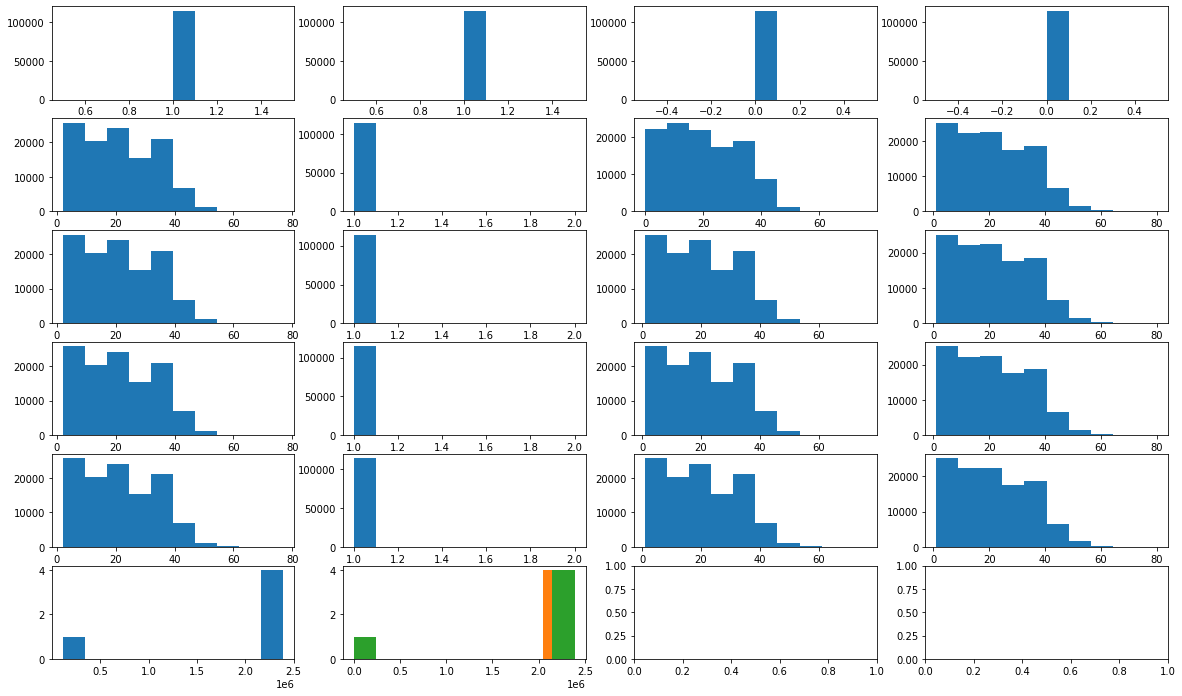

In [ ]:
fig, ax = plt.subplots(k + 2, 4, figsize=(20, 12))
for khop in range(k + 1):
    ax[khop][0].hist(num_nodes[khop])
    ax[khop][1].hist(num_users[khop])
    ax[khop][2].hist(num_items[khop])
    ax[khop][3].hist(num_edges[khop])
ax[k + 1][0].hist([sum(nodes) for nodes in num_nodes])
ax[k + 1][1].hist([sum(users) for users in num_users])
ax[k + 1][1].hist([sum(items) for items in num_items])
ax[k + 1][1].hist([sum(edges) for edges in num_edges])
plt.show()

In [6]:
import torch
import pickle
from DGSR import DGSR
from utils import get_collate, StaticData
from torch.utils.data import DataLoader
from torch import optim, nn

load = 'static/Enrollments_4_25/bs50_lr0.001_ep30_l20.0001_ft0.0_at0.0_ln3_hs50_mu25_mi5_k3_bce.out'
margin = False
feat_drop = 0.0
attn_drop = 0.0
gpu = 2
epoch = 1

device = torch.device(f'cuda:{gpu}')
torch.cuda.set_device(device)
print(f"device: {device}")
#print(f"opt: {opt}")

data_path = 'static/Enrollments_4_25/'
metadata_path = 'static/Enrollments_4_25/meta'
test_path = 'static/Enrollments_4_25/test/'
neg_path = 'static/Enrollments_4_25/neg'

with open(metadata_path, 'rb') as file:
    metadata = pickle.load(file)
    user_num = metadata['user_num']
    item_num = metadata['item_num']
    etypes = metadata['etypes']

with open(neg_path, 'rb') as f:
    data_neg = pickle.load(f) # negatives for evaluation
    
test_set = StaticData(test_path)
collate_test = get_collate(item_num, 25, 5, 3, False, data_neg)
test_data = DataLoader(dataset=test_set, batch_size=50, collate_fn=collate_test, shuffle=True, pin_memory=True, num_workers=12)

# initialize the model
model = DGSR(etypes=etypes, user_num=user_num, item_num=item_num, input_dim=50, max_lookback=25, 
             feat_drop=feat_drop, attn_drop=attn_drop, layer_num=3).cuda()

state = torch.load(load)
model.load_state_dict(state)
#optimizer = optim.Adam(model.parameters(), lr=opt.lr, weight_decay=opt.l2)
Loss = nn.MultiLabelMarginLoss if margin else nn.BCEWithLogitsLoss
loss_func = Loss(reduction='mean').to(device)
best = {}
stop_num = 0
epoch_start = None

for epoch in range(epoch):
	stop = True
	epoch_loss = 0
	val_loss = 0
	test_loss = 0
	iter = 0
		
	############################ test ############################
	print('start testing: ', datetime.datetime.now())
	ranks, neg_idxs = [], []
	iter = 0
	with torch.no_grad():
		for batch_graph, user, target, all_label, num_pos in test_data:
			iter += 1
			batch_graph = batch_graph.to(device)
			user = user.cuda()
			target = target.cuda()
			all_label = all_label.cuda()
			num_pos = num_pos.cuda()
			score, all_score = model(batch_graph, user, all_label=all_label, is_training=False)
			if margin:
				score = torch.sigmoid(score)
			loss = loss_func(score, target)
			test_loss += loss.cpu().item()
			perm = torch.randperm(all_score.shape[-1])
			all_score = -all_score[..., perm]
			rank = all_score.argsort(-1).argsort(-1)
			rank = rank[..., torch.argsort(perm)]
			ranks.append(rank)
			neg_idxs.append(num_pos)
			if iter % 200 == 0:
				if not opt.nosave:
					all_score = all_score[..., torch.argsort(perm)]
					#torch.save(score, results_path + f"test_score_{epoch}_{iter}")
					#torch.save(rank, results_path + f"test_rank_{epoch}_{iter}")
					#torch.save(all_score, results_path + f"test_all_score_{epoch}_{iter}")
				print('\tIter {}, test_loss {:.4f}'.format(iter, test_loss / iter), datetime.datetime.now(), flush=True)
			del user, target, score, loss, all_label, perm, all_score
			torch.cuda.empty_cache()
		ranks = torch.cat(ranks, 0)
		neg_idxs = torch.cat(neg_idxs, 0)
		results = eval_metric(ranks, neg_idxs, device)
	for metric_name, val in results.items():
		if metric_name not in best or val > best[metric_name][0]:
			stop = metric_name not in best   # stop=False when val exceeds best_result
			best[metric_name] = (val, epoch)
		if epoch == best[metric_name][1] and not opt.nosave:
			file_add = '' if metric_name == 'recall@10' else f'_{metric_name}'
			#torch.save(model.state_dict(), model_file + file_add)
	if stop:
		stop_num += 1
	else:
		stop_num = 0
	results_str = '\n'.join([f"{metric_name}: {val:.4f}" for metric_name, val in results.items()])
	print(f"train_loss:{epoch_loss:.4f} \
			\ntest_loss:{test_loss / iter:.4f} \
			\n{results_str}", flush=True)
	print('Epoch {}'.format(epoch + 1), '=============================================')

start testing:  2022-08-01 17:03:06.867149


NameError: name 'device' is not defined

(array([[22.,  0.,  0., ...,  0.,  0.,  3.],
        [22.,  0.,  0., ...,  0.,  0.,  3.],
        [22.,  0.,  0., ...,  0.,  0.,  3.],
        ...,
        [22.,  0.,  0., ...,  0.,  0.,  3.],
        [22.,  0.,  0., ...,  0.,  0.,  3.],
        [22.,  0.,  0., ...,  0.,  0.,  3.]]),
 array([4.7992240e-04, 5.0431930e-02, 1.0038394e-01, 1.5033595e-01,
        2.0028795e-01, 2.5023997e-01, 3.0019197e-01, 3.5014397e-01,
        4.0009600e-01, 4.5004800e-01, 5.0000000e-01], dtype=float32),
 <a list of 4925 BarContainer objects>)

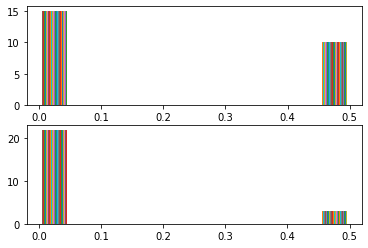

In [4]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import torch
pos_weights = [0.5, 1.0, 2.0]
dir = "static/Enrollments_4_25_False/bs25_lr0.001_ep30_l20.0001_pw1.0_ft0.0_at0.2_ln3_hs50_mu25_mi25_k3_bce/"=]

fig, ax = plt.subplots(2, 3)
for i, dir in enumerate(dirs):
    score = torch.load(dir + 'score_0_1000')
    all_score = torch.load(dir + 'test_score_0_1000')
    ax[0][i].hist(torch.sigmoid(score).detach().cpu().numpy())
    ax[1][i].hist(torch.sigmoid(all_score).detach().cpu().numpy())

In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv('data/Enrollments.csv')
print(data['time'].max())

23


In [20]:
new_items = np.setdiff1d(data[data['time'] > 19]['item_id'].values, data[data['time'] < 20]['item_id'].values)
print(f'there are {len(new_items)} courses in the last 4 semesters not in the previous 19')
new_data = data[data['time'] > 19]
new_str = f"there were {len(new_data)} enrollment records in {len(new_data['item_id'].unique())} unique courses in the last 4 semesters "
new_str += f"among {len(new_data['user_id'].unique())} students, for an average of "
new_str += f"{len(new_data) / len(new_data['user_id'].unique()):2f} courses per student over all 4 semesters"
print(new_str)
only_new = new_data[new_data['item_id'].isin(new_items)]
only_new_str = f"among the {len(new_items)} new courses in the last 4 semesters, there were "
only_new_str += f"{len(only_new)} enrollment records among {len(only_new['user_id'].unique())} " 
all_item = new_data[new_data['user_id'].isin(only_new['user_id'].unique())]
only_new_str += f"users who enrolled in {len(all_item)} courses, for an average of "
only_new_str += f"{len(all_item) / len(only_new['user_id'].unique())} courses per student over all 4 semesters. "
only_new_str += f"These enrollment records are {100 * len(only_new) / len(new_data):2f}% of all enrollments "
only_new_str += f"and {100 * len(only_new) / len(all_item):2f}% of the enrollments of the users who took a new course."
print(only_new_str)

there are 241 courses in the last 4 semesters not in the previous 19
there were 388197 enrollment records in 3284 unique courses in the last 4 semesters among 40266 students, for an average of 9.640814 courses per student over all 4 semesters
among the 241 new courses in the last 4 semesters, there were 17939 enrollment records among 10621 users who enrolled in 122146 courses, for an average of 11.50042368891818 courses per student over all 4 semesters. These enrollment records are 4.621107% of all enrollments and 14.686523% of the enrollments of the users who took a new course.


([Graph(num_nodes={'item': 4925, 'user': 114582},
      num_edges={('item', 'by', 'user'): 2387605, ('user', 'pby', 'item'): 2387605},
      metagraph=[('item', 'user', 'by'), ('user', 'item', 'pby')])], {})


/home/kiranganeshan/.local/lib/python3.8/site-packages/torch/nn/functional.py:1933: UserWarning: nn.functional.tanh is deprecated. Use torch.tanh instead.
  warnings.warn("nn.functional.tanh is deprecated. Use torch.tanh instead.")


positive samples


,cid,abbr_cid,course_title,course desc
257,194,PHYSICS_8A,Introductory Physics,"Introduction to forces, kinetics, equilibria, ..."
327,255,BIOLOGY_1A,General Biology Lecture,General introduction to cell structure and fun...
500,379,BIOLOGY_1AL,General Biology Laboratory,Laboratory that accompanies 1A lecture course....
1627,939,CHEM_301C,Chemistry 3 Lab Assistant,The Chemistry Undergraduate Teacher Scholar Pr...
4542,2183,EDUC_130,Knowing and Learning in Mathematics and Science,This course offers a sequence of collaborative...
10686,4404,NaN,NaN,Directed Group Stdy




all samples


,cid,abbr_cid,course_title,course desc
10,8,MATH_54,Linear Algebra and Differential Equations,Basic linear algebra; matrix arithmetic and de...
9,8,MATH_N54,Linear Algebra and Differential Equations,Basic linear algebra; matrix arithmetic and de...
519,396,CHEM_3A,Chemical Structure and Reactivity,"Introduction to organic chemical structures, b..."
208,150,PHYSED_1,Physical Education Activities,"Instruction in a variety of sports, exercise, ..."
543,416,ECON_1,Introduction to Economics,A survey of economics designed to give an over...
342,269,BIOLOGY_1B,General Biology Lecture and Laboratory,"General introduction to plant development, for..."
7202,3311,PB HLTH_116,"Seminar on Social, Political, and Ethical Issu...",This course offers an introduction to issues a...
756,509,CHEM_N3AL,Organic Chemistry Laboratory,Introduction to the theory and practice of met...
755,509,CHEM_3AL,Organic Chemistry Laboratory,Introduction to the theory and practice of met...
257,194,PHYSICS_8A,Introductory Physics,"Introduction to forces, kinetics, equilibria, ..."


...

,cid,abbr_cid,course_title,course desc
10,8,MATH_54,Linear Algebra and Differential Equations,Basic linear algebra; matrix arithmetic and de...
9,8,MATH_N54,Linear Algebra and Differential Equations,Basic linear algebra; matrix arithmetic and de...
257,194,PHYSICS_8A,Introductory Physics,"Introduction to forces, kinetics, equilibria, ..."
6996,3193,PHYS ED_11,Physical Education Activities,Variety of intercollegiate sports for men. Stu...
500,379,BIOLOGY_1AL,General Biology Laboratory,Laboratory that accompanies 1A lecture course....
556,426,CHEM_3B,Chemical Structure and Reactivity,"Conjugation, aromatic chemistry, carbonyl comp..."
327,255,BIOLOGY_1A,General Biology Lecture,General introduction to cell structure and fun...
10510,4228,NaN,NaN,Intro Human Nutr
42,35,CHEM_3BL,Organic Chemistry Laboratory,The synthesis and purification of organic comp...
547,420,COMPSCI_61C,Great Ideas of Computer Architecture (Machine ...,The internal organization and operation of dig...




800 samples


,cid,abbr_cid,course_title,course desc
519,396,CHEM_3A,Chemical Structure and Reactivity,"Introduction to organic chemical structures, b..."
257,194,PHYSICS_8A,Introductory Physics,"Introduction to forces, kinetics, equilibria, ..."
628,474,XMATH_1B,Calculus,Continuation of 1A. Techniques of integration;...
627,474,MATH_N1B,Calculus,Continuation of 1A. Techniques of integration;...
626,474,MATH_1B,Calculus,Continuation of 1A. Techniques of integration;...
500,379,BIOLOGY_1AL,General Biology Laboratory,Laboratory that accompanies 1A lecture course....
327,255,BIOLOGY_1A,General Biology Lecture,General introduction to cell structure and fun...
893,616,UGBA_196,Special Topics in Business Administration,Study in various fields of business administra...
143,104,NUSCTX_10,Introduction to Human Nutrition,This course focuses on relationships between d...
432,326,MATH_N16B,Analytic Geometry and Calculus,Continuation of 16A. Application of integratio...




900 samples


,cid,abbr_cid,course_title,course desc
257,194,PHYSICS_8A,Introductory Physics,"Introduction to forces, kinetics, equilibria, ..."
500,379,BIOLOGY_1AL,General Biology Laboratory,Laboratory that accompanies 1A lecture course....
327,255,BIOLOGY_1A,General Biology Lecture,General introduction to cell structure and fun...
893,616,UGBA_196,Special Topics in Business Administration,Study in various fields of business administra...
1496,856,EDUC_97,Field Studies,University organized and supervised field prog...
1495,856,EDUC_197,Field Studies,University organized and supervised field prog...
286,218,PHYSICS_7B,Physics for Scientists and Engineers,"Heat, electricity, and magnetism."
473,355,SOCIOL_1,Introduction to Sociology,Introduces students who are considering majori...
7002,3199,PHYS ED_12,Physical Education Activities,Variety of intercollegiate sports for women. S...
6951,3160,EL ENG_40,Introduction to Electrical Engineering,Fundamental circuit concepts and analysis tech...


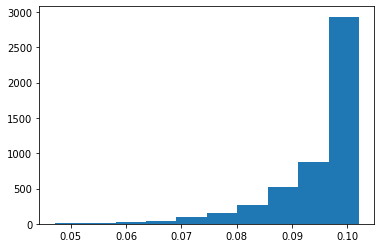

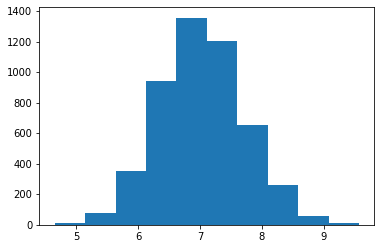

In [9]:
%matplotlib inline
import torch, dgl, pickle, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from DGNN import DGNN
from IPython.display import display
from utils import subsample, get_topk_items, multihot

fake_user = False

# data
max_lookback = 12
test_num = 4
data_id = f"Enrollments_{test_num}_{max_lookback}_False"
run_id = ''
name = None
old_run = False

# model
margin = False
sampling = True
multiplier = 1
hypers = OrderedDict([
	('bs', 25),
	('lr', 0.001),
	('ep', 30),
	('l2', 0.0001),
	('pw', 1.0),
	('ft', 0.0),
	('at', 0.2),
	('ln', 3),
	('hs', 50),
	('mu', 25),
	('mi', 25),
	('k', 3)
])

# eval
ats = [5, 10, 20]
neg_num = 100

# retrieve model state
if old_run:
    data_id = 'old_runs'
    run_id = name
else:
    suffix = '_'.join([f'{key}{val}' for key, val in hypers.items()])
    suffix = suffix + '_' + ('margin' if margin else 'bce')
    if not run_id:
        run_id = suffix
    else:
        run_id = run_id + '_' + suffix
state = torch.load(f"static/{data_id}/{run_id}/model")
with open(f"static/{data_id}/meta", 'rb') as f:
    meta = pickle.load(f)
    user_num = meta['user_num']
    item_num = meta['item_num']
    etypes = meta['etypes']
    
# load model and graphs
model = DGNN(etypes, user_num, item_num, hypers['hs'], max_lookback, hypers['ft'], hypers['at'], hypers['ln'])
model.load_state_dict(state)
graphs, labels = dgl.load_graphs(f"static/{data_id}/test/23.bin")
graph = graphs[0]

# collate
if fake_user:
    graph.add_nodes(1, ntype='user')
    user = torch.tensor([graph.num_nodes('user') - 1])
    predict_time = torch.tensor([23])
    past_items = torch.tensor([])
    past_times = torch.tensor([])
    edges = (user.repeat(len(past_items)), past_items)
    e_data = {'time': past_times, 'predict_time': predict_time.repeat(len(past_items))}
    graph.add_edges(edges, data=e_data, ntype='item')	
else:
    idx = torch.randint(labels['users'].shape[0], (1,))
    user = labels['users'][idx]
    label = labels['items'][idx, :]
    num_target = labels['num_items'][idx]
target = multihot(label, num_target, item_num)
samples = [subsample(graph, user, hypers['mi'], hypers['mu'], hypers['k']) for _ in range(multiplier)]
graph, u = zip(*samples)
user = torch.cat(u).long()
batch = dgl.batch(graph)

# run model and get topk items

user = user.cuda()
device = torch.get_device(user)
model = model.to(device)
batch = batch.to(device)
target = target.cuda()
num_taret = num_target.cuda()
all_sample_top = {}
with torch.no_grad():
	score = model(batch, user)
	score = score.reshape(-1, multiplier, item_num).mean(1)
	top, sample_top = get_topk_items(score, target, num_target, max(ats), neg_num)
	for n in range(100, 1000, 100):
		_, s = get_topk_items(score, target, num_target, max(ats), n)
		all_sample_top[n] = s.squeeze().cpu()
	top = top.squeeze().cpu()
	sample_top = sample_top.squeeze().cpu()

# get item descriptions
cid_desc = pd.read_csv('data/ucb_raw_data/courses.csv')
abbr_desc = pd.read_csv('data/ucb_raw_data/course_catalog_description.tsv', sep='\t')
courses = cid_desc.merge(abbr_desc, left_on='course desc', right_on='course_description', how='left')
courses = courses[['cid', 'abbr_cid', 'course_title', 'course desc']].sort_values('cid')
def reorder(courses, top):
    courses = courses.copy()
    top = top.cpu().numpy()
    courses = courses[courses['cid'].isin(top.tolist())]
    matrix = (courses['cid'].values[:, None] == top[None, :])
    ranks = np.arange(0, len(top))[None, :]
    courses['idx'] = np.argmin((1. - matrix) * len(top) + ranks, -1)
    return courses.sort_values('idx').drop(columns='idx')
if not fake_user:
    print("positive samples")
    display(courses[courses['cid'].isin(label.tolist()[0])])
print("\n\nall samples")
display(reorder(courses, top))
# print("100 samples")
# display(courses[courses['cid'].isin(sample_top.tolist())])
for key, t in all_sample_top.items():
    print(f"\n\n{key} samples")
    display(reorder(courses, t))


In [ ]:
plt.hist(torch.norm(model.item_embedding.weight, dim=-1).tolist())
plt.show()
from torch import nn
class D(nn.Module):
    def __init__(self):
        super(D, self).__init__()
        self.mod = nn.Embedding(4925, 50)
    
    def reset_parameters(self):
            gain = nn.init.calculate_gain('relu')
            for weight in self.parameters():
                if weight.dim() > 1:
                    nn.init.xavier_normal_(weight, gain=gain)
model = D()
plt.hist(torch.norm(model.mod.weight, dim=-1).tolist())
plt.show()